# Nigeria Baseline Model (Road **Links**, not aggregated roads)

This notebook builds a baseline classification model using **link-level Sentinel-2 records** from:

- `/Users/miranda/Documents/GitHub/Sentinel-FYP/data/nigeria_s2/nigeria_s2_2020_Q*.csv`

Key design choice:
- We treat each `system:index` as a **road link ID**.
- We do **group-aware splitting by link ID** so the same link does not appear in both train and test.

This avoids leakage and keeps the model genuinely link-level.


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")

S2_DIR = Path("/Users/miranda/Documents/GitHub/Sentinel-FYP/data/nigeria_s2")
csv_files = sorted(S2_DIR.glob("nigeria_s2_2020_Q*.csv"))
print(f"Found {len(csv_files)} S2 files")
for f in csv_files:
    print(" -", f.name)


Found 4 S2 files
 - nigeria_s2_2020_Q1.csv
 - nigeria_s2_2020_Q2.csv
 - nigeria_s2_2020_Q3.csv
 - nigeria_s2_2020_Q4.csv


In [2]:
# Load all 2020 quarter files (link-level rows)
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
print("Rows loaded:", len(df))
print("Columns:", len(df.columns))
df.head(3)


Rows loaded: 63812
Columns: 22


,system:index,B11,B12,B2,B3,B4,B8,BSI,ID,NDBI,...,NDWI,ROADCODE,ROADCODE_N,ROADNAME,SURFACECON,chunk,chunk_rand,quarter,year,.geo
0,0000000000000000355b,2681.813790,2091.311445,970.076923,1147.619137,1242.249531,2226.786585,0.101719,18717,0.092455,...,-0.320558,0314-00225,0314-00225,Ikot Abia Idem-Ndiya Etok [Ikono],NaN,1,0.957202,Q1,2020,"{""type"":""LineString"",""coordinates"":[[7.7206124..."
1,00000000000000003a2f,4415.000000,3796.000000,1275.000000,1874.000000,2594.000000,3320.000000,0.208032,20183,0.141564,...,-0.278398,2017-00229,2017-00229,Kwasangwami Babawa,NaN,1,0.554406,Q1,2020,"{""type"":""Point"",""coordinates"":[8.6574338772862..."
2,00000000000000000394,4472.181308,3409.769576,864.403171,1342.141173,2066.927449,2947.949761,0.263417,2058,0.205485,...,-0.374858,2216-00238,2216-00238,Dirin Daji - Makuku,NaN,1,0.994691,Q1,2020,"{""type"":""LineString"",""coordinates"":[[5.5026198..."


In [3]:
# Confirm this is link-level data
print("Unique link IDs (system:index):", df["system:index"].nunique(dropna=True))
print("Unique ROADCODE_N (road codes):", df["ROADCODE_N"].nunique(dropna=True))
print("Quarters:", sorted(df["quarter"].dropna().unique()))
print("Road condition labels:")
print(df["SURFACECON"].value_counts(dropna=False))


Unique link IDs (system:index): 15953
Unique ROADCODE_N (road codes): 4573
Quarters: ['Q1', 'Q2', 'Q3', 'Q4']
Road condition labels:
SURFACECON
Poor         25808
Fair         17516
Very Poor    11820
Good          6780
Excellent     1872
NaN             16
Name: count, dtype: int64


In [4]:
# Merge in additional local shapefile attributes (ROAD CONDITION / NETWORK / PAVEMENT)
DATA_ROOT = Path("/Users/miranda/Documents/GitHub/Sentinel-FYP/data")

cond_candidates = list(DATA_ROOT.rglob("RoadCondition.shp"))
if not cond_candidates:
    raise FileNotFoundError("RoadCondition.shp not found under data folder")

SHAPE_DIR = cond_candidates[0].parent
print("Using shapefile folder:", SHAPE_DIR)

road_cond = gpd.read_file(SHAPE_DIR / "RoadCondition.shp")
road_net = gpd.read_file(SHAPE_DIR / "RoadNetwork.shp")
road_pave = gpd.read_file(SHAPE_DIR / "RoadPavement.shp")


def norm_code(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.upper()
    )

# Build normalized key in each source
for gdf in (road_cond, road_net, road_pave):
    if "ROADCODE" not in gdf.columns:
        raise ValueError("Expected ROADCODE in shapefile source")
    gdf["ROADCODE_N"] = norm_code(gdf["ROADCODE"])

df["ROADCODE_N"] = norm_code(df["ROADCODE_N"])

# Keep only needed columns from each local table
cond_small = road_cond[["ROADCODE_N", "SURFACECON"]].drop_duplicates("ROADCODE_N")
net_small = road_net[["ROADCODE_N", "ROADCLASS"]].drop_duplicates("ROADCODE_N") if "ROADCLASS" in road_net.columns else road_net[["ROADCODE_N"]].drop_duplicates("ROADCODE_N")
pave_small = road_pave[["ROADCODE_N", "PAVETYPE"]].drop_duplicates("ROADCODE_N") if "PAVETYPE" in road_pave.columns else road_pave[["ROADCODE_N"]].drop_duplicates("ROADCODE_N")

# Merge onto S2 link-level table
merged = (
    df
    .merge(cond_small, on="ROADCODE_N", how="left", suffixes=("", "_cond"))
    .merge(net_small, on="ROADCODE_N", how="left", suffixes=("", "_net"))
    .merge(pave_small, on="ROADCODE_N", how="left", suffixes=("", "_pave"))
)

# Prefer local shapefile labels if present
if "SURFACECON_cond" in merged.columns:
    merged["SURFACECON"] = merged["SURFACECON_cond"].combine_first(merged.get("SURFACECON"))
if "ROADCLASS_net" in merged.columns:
    merged["ROADCLASS"] = merged["ROADCLASS_net"].combine_first(merged.get("ROADCLASS"))
if "PAVETYPE_pave" in merged.columns:
    merged["PAVETYPE"] = merged["PAVETYPE_pave"].combine_first(merged.get("PAVETYPE"))

# Drop helper/suffixed columns
drop_cols = [c for c in merged.columns if c.endswith("_cond") or c.endswith("_net") or c.endswith("_pave")]
merged = merged.drop(columns=drop_cols, errors="ignore")

df = merged
print("Rows after merge:", len(df))
print("SURFACECON non-null:", df["SURFACECON"].notna().sum())
print("ROADCLASS non-null:", df["ROADCLASS"].notna().sum() if "ROADCLASS" in df.columns else 0)
print("PAVETYPE non-null:", df["PAVETYPE"].notna().sum() if "PAVETYPE" in df.columns else 0)


Using shapefile folder: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/NirTIMS Shapefiles Nov 14 2025
Rows after merge: 63812
SURFACECON non-null: 63808
ROADCLASS non-null: 63812
PAVETYPE non-null: 63444


In [5]:
# Merge ProblemAreas.shp features (supervised signal enrichment)
problem_path = SHAPE_DIR / "ProblemAreas.shp"
if problem_path.exists():
    pa = gpd.read_file(problem_path).copy()

    if "ROADCODE" not in pa.columns:
        raise ValueError("ProblemAreas.shp found but ROADCODE column is missing")

    pa["ROADCODE_N"] = norm_code(pa["ROADCODE"])

    keep_pa = ["ROADCODE_N"]
    for c in ["PATYPE", "PAINTERVEN", "PALENGTH"]:
        if c in pa.columns:
            keep_pa.append(c)
    pa = pa[keep_pa].copy()

    if "PALENGTH" in pa.columns:
        pa["PALENGTH"] = pd.to_numeric(pa["PALENGTH"], errors="coerce")
    if "PAINTERVEN" in pa.columns:
        pa["PAINTERVEN"] = pd.to_numeric(pa["PAINTERVEN"], errors="coerce")

    pa_agg = pa.groupby("ROADCODE_N").size().rename("pa_count").to_frame()

    if "PALENGTH" in pa.columns:
        pa_agg["pa_len_sum"] = pa.groupby("ROADCODE_N")["PALENGTH"].sum(min_count=1)
        pa_agg["pa_len_mean"] = pa.groupby("ROADCODE_N")["PALENGTH"].mean()

    if "PAINTERVEN" in pa.columns:
        pa_agg["pa_interv_mean"] = pa.groupby("ROADCODE_N")["PAINTERVEN"].mean()

    if "PATYPE" in pa.columns:
        tmp = pa[["ROADCODE_N", "PATYPE"]].copy()
        tmp["PATYPE"] = tmp["PATYPE"].astype(str).str.strip()
        top_types = tmp["PATYPE"].value_counts().head(8).index.tolist()
        d = pd.get_dummies(tmp["PATYPE"], prefix="patype")
        keep_cols = [f"patype_{t}" for t in top_types if f"patype_{t}" in d.columns]
        d = d[keep_cols]
        d["ROADCODE_N"] = tmp["ROADCODE_N"].values
        patype_counts = d.groupby("ROADCODE_N").sum()
        pa_agg = pa_agg.join(patype_counts, how="left")

    pa_agg = pa_agg.reset_index().fillna(0)
    df = df.merge(pa_agg, on="ROADCODE_N", how="left")

    pa_cols = [c for c in pa_agg.columns if c != "ROADCODE_N"]
    for c in pa_cols:
        df[c] = df[c].fillna(0)

    print("ProblemAreas merged. Added columns:", pa_cols)
else:
    print("ProblemAreas.shp not found. Proceeding without problem-area features.")


ProblemAreas merged. Added columns: ['pa_count', 'pa_len_sum', 'pa_len_mean', 'pa_interv_mean', 'patype_Erosion', 'patype_Waterlogging', 'patype_Landslide']


In [6]:
# Keep only rows needed for baseline modeling (after shapefile + ProblemAreas merge)
feature_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI", "B2", "B3", "B4", "B8", "B11", "B12"]
required = ["system:index", "quarter", "year", "SURFACECON", "ROADCLASS", "PAVETYPE"] + feature_cols

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in input CSV(s): {missing}")

# optional problem columns (if present)
extra_cols = [c for c in df.columns if c.startswith("pa_") or c.startswith("patype_")]
m = df[required + extra_cols].copy()

# Normalize key strings
m["SURFACECON"] = m["SURFACECON"].astype(str).str.strip()
m = m[m["SURFACECON"].isin(["Very Poor", "Poor", "Fair", "Good", "Excellent"])].copy()

# Numeric cleanup for Sentinel features
for c in feature_cols:
    m[c] = pd.to_numeric(m[c], errors="coerce")

# Numeric cleanup for optional features
for c in extra_cols:
    m[c] = pd.to_numeric(m[c], errors="coerce").fillna(0)

# Remove impossible NDVI-range values and rows with missing core indices
m = m[(m["NDVI"] >= -1) & (m["NDVI"] <= 1)]
m = m.dropna(subset=["NDVI", "NDMI", "NDBI", "NDWI", "BSI"])

# Add quarter number to keep season signal in baseline model
quarter_map = {"Q1":1,"Q2":2,"Q3":3,"Q4":4,
               "Jan–Mar":1,"Apr–Jun":2,"Jul–Sep":3,"Oct–Dec":4,
               "Jan-Mar":1,"Apr-Jun":2,"Jul-Sep":3,"Oct-Dec":4}
m["qnum"] = m["quarter"].map(quarter_map).astype("Int64")

print("Rows after cleaning:", len(m))
print("Unique links after cleaning:", m["system:index"].nunique())
print("Optional problem columns used:", extra_cols)
m.head(3)


Rows after cleaning: 47179
Unique links after cleaning: 15763
Optional problem columns used: ['pa_count', 'pa_len_sum', 'pa_len_mean', 'pa_interv_mean', 'patype_Erosion', 'patype_Waterlogging', 'patype_Landslide']


,system:index,quarter,year,SURFACECON,ROADCLASS,PAVETYPE,NDVI,NDMI,NDBI,NDWI,...,B11,B12,pa_count,pa_len_sum,pa_len_mean,pa_interv_mean,patype_Erosion,patype_Waterlogging,patype_Landslide,qnum
0,0000000000000000355b,Q1,2020,Fair,Trunk C Township,EARTHEN,0.284726,-0.092455,0.092455,-0.320558,...,2681.813790,2091.311445,8.0,39.0,4.875000,0.0,3.0,4.0,1.0,1
2,00000000000000000394,Q1,2020,Poor,Trunk C Feeder,DBST,0.176261,-0.205485,0.205485,-0.374858,...,4472.181308,3409.769576,23.0,727.0,31.608696,0.0,14.0,8.0,1.0,1
3,00000000000000003909,Q1,2020,Very Poor,Trunk C Feeder,ASPHALT CONCRETE,0.161027,-0.163813,0.163813,-0.318867,...,5353.519682,4379.022613,1.0,200.0,200.000000,0.0,0.0,1.0,0.0,1


## Target setup

We provide two targets:
- `target_5`: original 5 classes (`Very Poor`, `Poor`, `Fair`, `Good`, `Excellent`)
- `target_3`: merged baseline classes:
  - `low` = Very Poor + Poor
  - `med` = Fair
  - `high` = Good + Excellent

Change `TARGET_MODE` to choose the baseline task.


In [7]:
m["target_5"] = m["SURFACECON"]
map3 = {
    "Very Poor": "low",
    "Poor": "low",
    "Fair": "med",
    "Good": "high",
    "Excellent": "high",
}
m["target_3"] = m["SURFACECON"].map(map3)

TARGET_MODE = "target_3"   # change to "target_5" if needed

print("Target mode:", TARGET_MODE)
print(m[TARGET_MODE].value_counts())


Target mode: target_3
target_3
low     22294
med     17576
high     7309
Name: count, dtype: int64


In [8]:
# Feature matrix (Sentinel + quarter + optional problem features)
problem_cols = [c for c in m.columns if c.startswith("pa_") or c.startswith("patype_")]
model_features = feature_cols + ["qnum"] + problem_cols

X = m[model_features].copy()
y = m[TARGET_MODE].copy()
groups = m["system:index"].copy()  # <- split by link ID, not by row

# group-aware split prevents same link from leaking into both train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Train links:", groups.iloc[train_idx].nunique(), "| Test links:", groups.iloc[test_idx].nunique())
print("Total model features:", len(model_features))


Train rows: 35389 | Test rows: 11790
Train links: 11822 | Test links: 3941
Total model features: 19


RandomForest report:
              precision    recall  f1-score   support

        high      0.803     0.635     0.709      1817
         low      0.803     0.890     0.844      5665
         med      0.810     0.766     0.787      4308

    accuracy                          0.805     11790
   macro avg      0.805     0.764     0.780     11790
weighted avg      0.805     0.805     0.803     11790



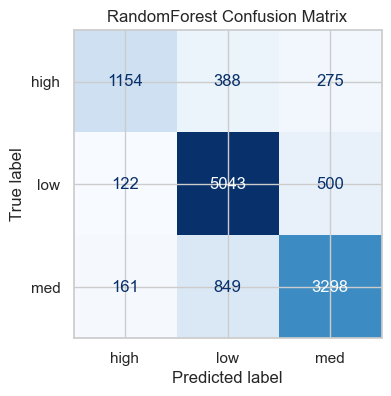

In [9]:
# Baseline 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("RandomForest report:")
print(classification_report(y_test, pred_rf, digits=3))

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, pred_rf, labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("RandomForest Confusion Matrix")
plt.show()


## Ablation: RandomForest **without** ProblemAreas features

This isolates how much predictive signal comes from Sentinel-2 + quarter only (no `pa_*` / `patype_*`).

RandomForest report (without ProblemAreas):
              precision    recall  f1-score   support

        high      0.501     0.277     0.357      1817
         low      0.629     0.716     0.670      5665
         med      0.527     0.530     0.528      4308

    accuracy                          0.580     11790
   macro avg      0.552     0.508     0.518     11790
weighted avg      0.572     0.580     0.570     11790



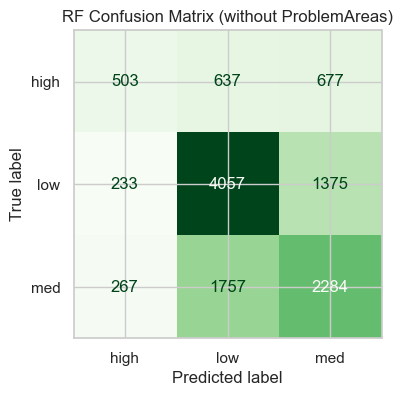

In [10]:
# RandomForest ablation (NO ProblemAreas features)
no_pa_features = feature_cols + ["qnum"]

X_no_pa = m[no_pa_features].copy()
X_train_no_pa = X_no_pa.iloc[train_idx]
X_test_no_pa = X_no_pa.iloc[test_idx]

rf_no_pa = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_no_pa.fit(X_train_no_pa, y_train)

pred_rf_no_pa = rf_no_pa.predict(X_test_no_pa)
print("RandomForest report (without ProblemAreas):")
print(classification_report(y_test, pred_rf_no_pa, digits=3))

labels = sorted(y_test.unique())
cm_no_pa = confusion_matrix(y_test, pred_rf_no_pa, labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm_no_pa, display_labels=labels).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("RF Confusion Matrix (without ProblemAreas)")
plt.show()

In [11]:
# Side-by-side comparison: WITH vs WITHOUT ProblemAreas
f1_rf_with_pa = f1_score(y_test, pred_rf, average="weighted")
f1_rf_without_pa = f1_score(y_test, pred_rf_no_pa, average="weighted")
macro_with_pa = f1_score(y_test, pred_rf, average="macro")
macro_without_pa = f1_score(y_test, pred_rf_no_pa, average="macro")

comparison_ablation = pd.DataFrame([
    {
        "model": "RF + S2 + quarter + ProblemAreas",
        "weighted_f1": f1_rf_with_pa,
        "macro_f1": macro_with_pa,
        "n_features": len(model_features),
    },
    {
        "model": "RF + S2 + quarter (no ProblemAreas)",
        "weighted_f1": f1_rf_without_pa,
        "macro_f1": macro_without_pa,
        "n_features": len(no_pa_features),
    }
])

comparison_ablation["delta_vs_with_pa_weighted"] = comparison_ablation["weighted_f1"] - f1_rf_with_pa
comparison_ablation["delta_vs_with_pa_macro"] = comparison_ablation["macro_f1"] - macro_with_pa
comparison_ablation

,model,weighted_f1,macro_f1,n_features,delta_vs_with_pa_weighted,delta_vs_with_pa_macro
0,RF + S2 + quarter + ProblemAreas,0.802595,0.780223,19,0.000000,0.000000
1,RF + S2 + quarter (no ProblemAreas),0.569856,0.518297,12,-0.232739,-0.261927


## Unsupervised Exploration (before regularized logistic)

These steps help us understand structure in the link-level feature space:
- **KMeans** clusters links into similar groups.
- **IsolationForest** flags anomalous links.

They are exploratory and complementary to supervised classification.


In [12]:
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

U = m[model_features].fillna(0).copy()
U_scaled = StandardScaler().fit_transform(U)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
m["cluster"] = kmeans.fit_predict(U_scaled)
print("KMeans silhouette score:", round(silhouette_score(U_scaled, m["cluster"]), 4))
print("Cluster vs SURFACECON (row-normalized):")
print(pd.crosstab(m["cluster"], m["SURFACECON"], normalize="index").round(3))

# IsolationForest anomaly detection
iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
m["anomaly_flag"] = iso.fit_predict(U_scaled)  # -1 anomaly, 1 normal
print("Anomaly flag counts:")
print(m["anomaly_flag"].value_counts())
print("Anomaly vs SURFACECON (row-normalized):")
print(pd.crosstab(m["anomaly_flag"], m["SURFACECON"], normalize="index").round(3))


KMeans silhouette score: 0.2608
Cluster vs SURFACECON (row-normalized):
SURFACECON  Excellent   Fair   Good   Poor  Very Poor
cluster                                              
0               0.035  0.323  0.136  0.378      0.128
1               0.002  0.412  0.389  0.170      0.028
2               0.031  0.457  0.123  0.296      0.093
3               0.020  0.335  0.067  0.424      0.154
4               0.046  0.312  0.061  0.415      0.165
Anomaly flag counts:
anomaly_flag
 1    45763
-1     1416
Name: count, dtype: int64
Anomaly vs SURFACECON (row-normalized):
SURFACECON    Excellent   Fair   Good   Poor  Very Poor
anomaly_flag                                           
-1                0.018  0.311  0.427  0.167      0.076
 1                0.030  0.374  0.116  0.359      0.120


/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic (elastic-net) report:
              precision    recall  f1-score   support

        high      0.281     0.498     0.359      1817
         low      0.616     0.498     0.551      5665
         med      0.478     0.443     0.460      4308

    accuracy                          0.478     11790
   macro avg      0.458     0.480     0.457     11790
weighted avg      0.514     0.478     0.488     11790



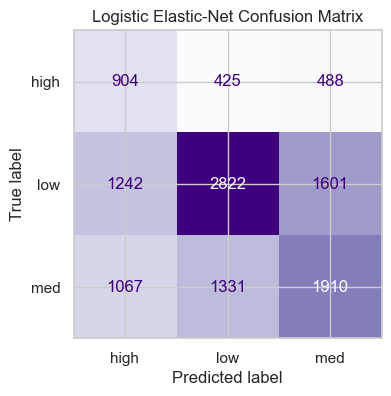

In [30]:
# Baseline 2: Logistic Regression (Elastic Net = L1/L2 regularization)
# Version-safe config (no multi_class arg)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        l1_ratio=0.5,
        C=1.0,
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

logit.fit(X_train, y_train)
pred_log = logit.predict(X_test)

print("Logistic (elastic-net) report:")
print(classification_report(y_test, pred_log, digits=3))

labels = sorted(y_test.unique())
cm2 = confusion_matrix(y_test, pred_log, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm2, display_labels=labels).plot(
    ax=ax, cmap="Purples", colorbar=False
)
ax.set_title("Logistic Elastic-Net Confusion Matrix")
plt.show()


In [31]:
# Compare weighted F1
f1_rf = f1_score(y_test, pred_rf, average="weighted")
f1_log = f1_score(y_test, pred_log, average="weighted")

pd.DataFrame({
    "model": ["RandomForest", "LogisticElasticNet"],
    "weighted_f1": [f1_rf, f1_log],
}).sort_values("weighted_f1", ascending=False)


,model,weighted_f1
0,RandomForest,0.802595
1,LogisticElasticNet,0.488179


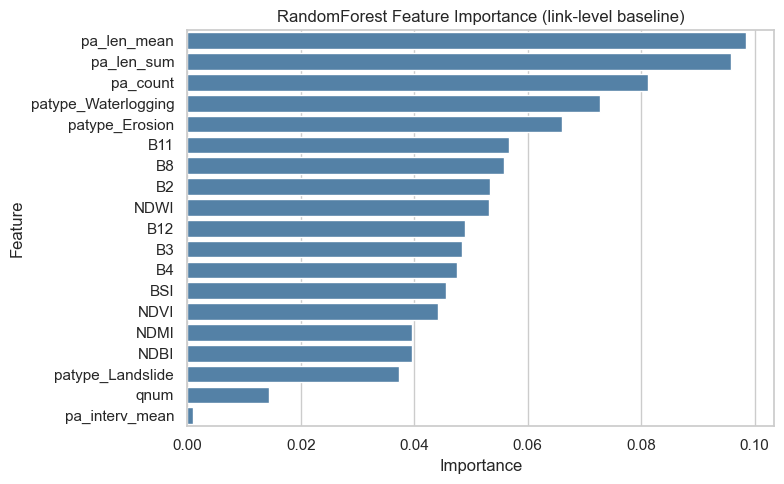

pa_len_mean            0.098497
pa_len_sum             0.095785
pa_count               0.081250
patype_Waterlogging    0.072769
patype_Erosion         0.066113
B11                    0.056639
B8                     0.055909
B2                     0.053327
NDWI                   0.053148
B12                    0.048949
B3                     0.048410
B4                     0.047613
BSI                    0.045603
NDVI                   0.044108
NDMI                   0.039684
NDBI                   0.039549
patype_Landslide       0.037228
qnum                   0.014384
pa_interv_mean         0.001034
dtype: float64

In [32]:
# RandomForest feature importance
imp = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("RandomForest Feature Importance (link-level baseline)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

imp


## Notes

- This is a **baseline** using only Sentinel-2 + quarter.
- It is link-level because splitting is by `system:index` (road link ID).
- Next improvements (optional):
  1. Add road attributes (`ROADCLASS`, `PAVETYPE`) through one-hot encoding.
  2. Add temporal features (e.g., per-link quarter-to-quarter deltas).
  3. Use GroupKFold CV by `system:index` for more robust estimates.
